In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use("ggplot")

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("D:/DLM Research/merged_data.csv")

In [3]:
df

,temp,dur_illness,exam_time,maternal_status,pnt_age_type,diag_gen_plan,other_phys_find,mss,weight,amtsl,...,pnt_mrn,resp_syst,pnt_age,presentation,cvs,Pat-ID,MRN,gest_age_y,neur_syst,Institution
0,NaN,NaN,NaN,NaN,years,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,24.0,NaN,NaN,1,2.0,NaN,NaN,Yekatit Hospital
1,NaN,NaN,NaN,Stable,years,NaN,NaN,NaN,NaN,Oxytocine,...,NaN,NaN,29.0,NaN,NaN,2,3.0,NaN,NaN,Yekatit Hospital
2,NaN,NaN,NaN,NaN,months,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,8.0,NaN,NaN,3,4.0,NaN,NaN,Yekatit Hospital
3,NaN,NaN,NaN,NaN,months,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,8.0,NaN,NaN,4,5.0,NaN,NaN,Yekatit Hospital
4,36.0,NaN,18:09:21,NaN,years,test,NaN,NaN,70.0,NaN,...,NaN,NaN,32.0,,NaN,5,6.0,NaN,NaN,Yekatit Hospital
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
646062,NaN,NaN,NaN,NaN,years,NaN,NaN,NaN,NaN,NaN,...,861121.0,NaN,17.0,NaN,NaN,261371,NaN,NaN,NaN,Zewuditu Hospital
646063,NaN,NaN,NaN,NaN,years,NaN,NaN,NaN,NaN,NaN,...,861122.0,NaN,25.0,NaN,NaN,261372,NaN,NaN,NaN,Zewuditu Hospital
646064,NaN,NaN,NaN,NaN,years,NaN,NaN,NaN,NaN,NaN,...,861123.0,NaN,23.0,NaN,NaN,261373,NaN,NaN,NaN,Zewuditu Hospital
646065,NaN,NaN,NaN,NaN,years,NaN,NaN,NaN,NaN,NaN,...,861124.0,NaN,45.0,NaN,NaN,261374,NaN,NaN,NaN,Zewuditu Hospital


# check row duplicates

In [4]:
# Check duplicates
print(df[['Pat-ID', 'delivery_date', 'Institution']].duplicated().sum())

12896


In [5]:
df.duplicated(subset=['Pat-ID', 'delivery_date', 'Institution']).sum()

12896

# Remove duplicates based on key identifiers 
## Keep first record (common choice)

In [6]:
df = df.drop_duplicates(subset=['Pat-ID', 'delivery_date', 'Institution'], keep='first')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 633171 entries, 0 to 646066
Data columns (total 55 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   temp                 69146 non-null   float64
 1   dur_illness          0 non-null       float64
 2   exam_time            69270 non-null   object 
 3   maternal_status      89762 non-null   object 
 4   pnt_age_type         458581 non-null  object 
 5   diag_gen_plan        68709 non-null   object 
 6   other_phys_find      1099 non-null    object 
 7   mss                  2956 non-null    object 
 8   weight               69146 non-null   float64
 9   amtsl                89688 non-null   object 
 10  record_time          89762 non-null   object 
 11  laceration           12549 non-null   object 
 12  Age                  174346 non-null  object 
 13  lgs                  3519 non-null    object 
 14  gis                  4396 non-null    object 
 15  record_date          8

In [8]:
# Drop columns where all values are null
df = df.dropna(axis=1, how='all')

In [9]:
threshold_row = 0.3 * df.shape[1]   # at least 40% non-missing required
df = df.dropna(axis=0, thresh=threshold_row)

In [10]:
df = df.dropna(subset=['delivery_mode'])

In [11]:
df

,temp,exam_time,maternal_status,pnt_age_type,diag_gen_plan,other_phys_find,mss,weight,amtsl,record_time,...,pnt_mrn,resp_syst,pnt_age,presentation,cvs,Pat-ID,MRN,gest_age_y,neur_syst,Institution
11,0.0,09:39:43,Stable,years,"CBC ,U/A ,BPP , CONSULT SENIOR RESIDENT",NaN,NaN,0.0,Oxytocine,21:29:45,...,NaN,NaN,32.0,NaN,NaN,9,10.0,NaN,NaN,Yekatit Hospital
20,3366.0,11:39:27,Stable,years,"CBC, U/A, obstetricU/S_x000D_\nconsult residents",NaN,NaN,0.0,Oxytocine,04:06:54,...,NaN,NaN,28.0,NaN,NaN,15,16.0,NaN,NaN,Yekatit Hospital
23,0.0,11:27:50,Stable,years,"_x000D_\nCBC, BG/RH, PICT, VDRL, HBsAG, Obs US...",NaN,NaN,0.0,Oxytocine,13:23:48,...,NaN,NaN,33.0,,NaN,18,19.0,NaN,NaN,Yekatit Hospital
25,0.0,12:17:39,Stable,years,CBC U\A OBS U/S,NaN,NaN,0.0,Oxytocine,19:07:02,...,NaN,NaN,26.0,breech,NaN,20,21.0,NaN,NaN,Yekatit Hospital
31,0.0,12:43:13,Stable,years,"CBC,U/A_x000D_\nObs U/S (BPP,est.Weight and Es...",No abdominal tenderness,NaN,0.0,Oxytocine,08:16:03,...,NaN,NaN,23.0,NaN,NaN,26,27.0,NaN,NaN,Yekatit Hospital
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
645713,NaN,NaN,Stable,years,NaN,NaN,NaN,NaN,Oxytocine,15:23:19,...,860772.0,NaN,38.0,NaN,NaN,261022,NaN,NaN,NaN,Zewuditu Hospital
645727,NaN,NaN,Stable,years,NaN,NaN,NaN,NaN,Oxytocine,18:08:02,...,860786.0,NaN,25.0,NaN,NaN,261036,NaN,NaN,NaN,Zewuditu Hospital
645741,0.0,14:08:40,Stable,years,Link for BPP,NaN,NaN,0.0,Oxytocine,05:09:30,...,860800.0,NaN,22.0,ceph,NaN,261050,NaN,41+0wk from 23+1wk U/S done on 2/3/18,NaN,Zewuditu Hospital
645758,NaN,NaN,Stable,years,NaN,NaN,NaN,NaN,Oxytocine,23:21:34,...,860817.0,NaN,29.0,NaN,NaN,261067,NaN,NaN,NaN,Zewuditu Hospital


In [12]:
# Check duplicates
df[['Pat-ID', 'delivery_date']].duplicated().sum()

8

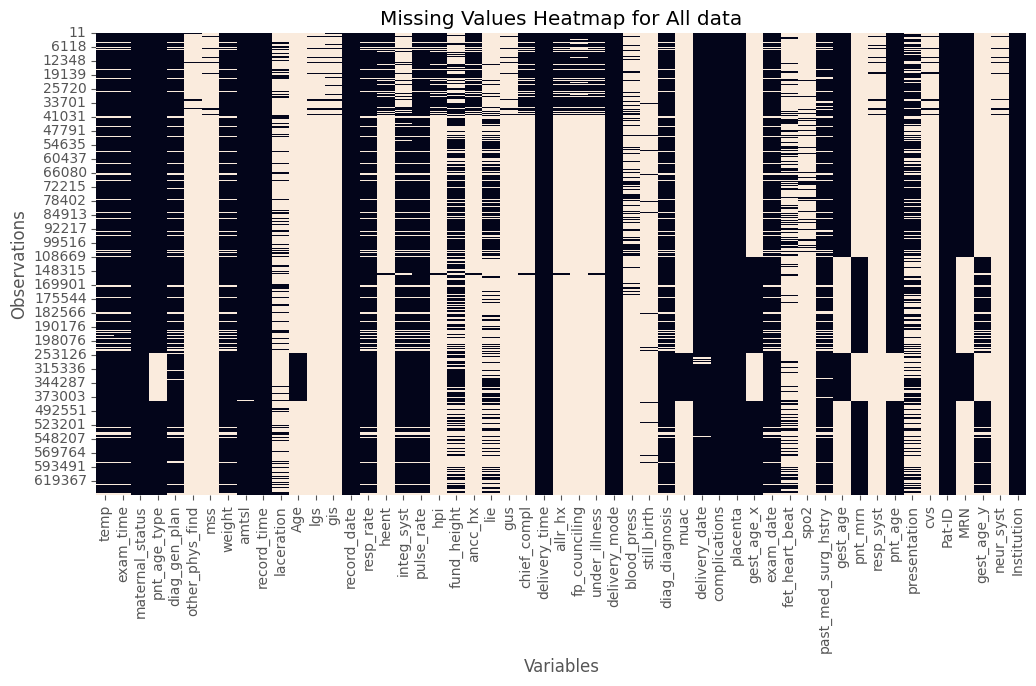

In [13]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap for All data")
plt.xlabel("Variables")
plt.ylabel("Observations")
plt.show()

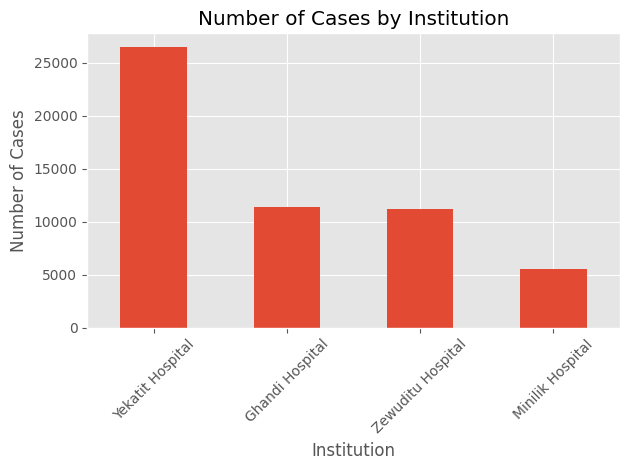

In [14]:
# Count number of cases per institution
counts = df['Institution'].value_counts()

# Plot
counts.plot(kind='bar')

# Labels and title
plt.xlabel('Institution')
plt.ylabel('Number of Cases')
plt.title('Number of Cases by Institution')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 54530 entries, 11 to 645847
Data columns (total 53 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   temp                 48200 non-null  float64
 1   exam_time            48298 non-null  object 
 2   maternal_status      54530 non-null  object 
 3   pnt_age_type         48968 non-null  object 
 4   diag_gen_plan        47865 non-null  object 
 5   other_phys_find      535 non-null    object 
 6   mss                  1410 non-null   object 
 7   weight               48200 non-null  float64
 8   amtsl                54489 non-null  object 
 9   record_time          54530 non-null  object 
 10  laceration           12119 non-null  object 
 11  Age                  5561 non-null   object 
 12  lgs                  1697 non-null   object 
 13  gis                  2149 non-null   object 
 14  record_date          54530 non-null  object 
 15  resp_rate            48200 non-null  fl

In [16]:
# Confirm changes
print(df['complications'].value_counts())

complications
none,                                                              50549
Others specify,                                                     1811
Pre-eclampsia,                                                      1043
APH,                                                                 335
PPH,                                                                 265
OL/Prolonged labor,                                                  121
epilepsy,                                                             95
retroviral infection,                                                 87
Eclampsia,                                                            53
none,Others specify,                                                  50
Ruptured Uterus,                                                      23
Pre-eclampsia,APH,                                                    18
epilepsy,none,                                                        15
PPH,none,                            

In [17]:
# Confirm changes
print(df['delivery_mode'].value_counts())

delivery_mode
Normal delivery SVD              18819
Caesarean section                17678
SVD                              12402
C/S                               4288
Vacuum extraction                  551
Assisted breech delivery           236
Forceps delivery                   218
Assisted Breech delivery           209
Episiotomy                          44
Abdominal surgical deliveries       28
Others                              17
Craniotomy                          14
Abdominal surgical delivery         11
Other                               10
Other Destructive delivery           5
Name: count, dtype: int64


In [18]:
# Work on a safe copy
df = df.copy()

# Standardize text
df['delivery_mode'] = (
    df['delivery_mode']
    .astype(str)
    .str.strip()
    .str.lower()
)

# Initialize new column
df['delivery_mode_clean'] = 'Other'

# 1. Normal Vaginal Delivery
mask_nvd = df['delivery_mode'].str.contains(
    r'\b(svd|normal delivery|spontaneous vaginal delivery)\b', na=False
)
df.loc[mask_nvd, 'delivery_mode_clean'] = 'Normal Vaginal Delivery'

# 2. Cesarean Section
mask_cs = df['delivery_mode'].str.contains(
    r'\b(c/s|caesarean|cesarean|abdominal surgical)\b', na=False
)
df.loc[mask_cs, 'delivery_mode_clean'] = 'Cesarean Section'

# 3. Assisted Vaginal Delivery
mask_avd = df['delivery_mode'].str.contains(
    r'\b(vacuum|Forceps |assisted breech|Breech)\b', na=False
)
df.loc[mask_avd, 'delivery_mode_clean'] = 'Assisted Vaginal Delivery'

# Check result
df['delivery_mode_clean'].value_counts()

delivery_mode_clean
Normal Vaginal Delivery      31221
Cesarean Section             22005
Assisted Vaginal Delivery      996
Other                          308
Name: count, dtype: int64

In [19]:
# Create a working copy of the DataFrame
df = df.copy()

# 1. Create an indicator column for Cesarean Section cases
df['Cesarean Section'] = df['delivery_mode_clean'].str.contains(
    r'Cesarean Section',  # Broad but targeted matching
    case=False, 
    na=False,
    regex=True
).astype(int)

df["Cesarean Section"].value_counts()

Cesarean Section
0    32525
1    22005
Name: count, dtype: int64

In [20]:
# Work on a safe copy
df = df.copy()

# Standardize text
df['presentation'] = (
    df['presentation']
    .astype(str)
    .str.strip()
    .str.lower()
)

# Initialize new column
df['presentation_clean'] = 'NA'

# 1. Cephalic (Vertex)
mask_cephalic = df['presentation'].str.contains(
    r'\b(ce|cephalic|ve|vertex|oc|occiput|oa|op)\b', na=False
)
df.loc[mask_cephalic, 'presentation_clean'] = 'Cephalic'

# 2. Breech
mask_breech = df['presentation'].str.contains(
    r'\b(br|breech|frank breech|complete breech|footling)\b', na=False
)
df.loc[mask_breech, 'presentation_clean'] = 'Breech'

# 3. Transverse / Shoulder
mask_transverse = df['presentation'].str.contains(
    r'\b(tran|transverse|sho|shoulder|obl|oblique)\b', na=False
)
df.loc[mask_transverse, 'presentation_clean'] = 'Transverse/Shoulder'

# 4. Face / Brow (less common but important)
mask_face = df['presentation'].str.contains(
    r'\b(face|brow)\b', na=False
)
df.loc[mask_face, 'presentation_clean'] = 'Face/Brow'

# Check distribution
df['presentation_clean'].value_counts(dropna=False)

presentation_clean
NA                     36790
Cephalic               15883
Breech                  1778
Transverse/Shoulder       79
Name: count, dtype: int64

In [21]:
# Work on a safe copy
df = df.copy()

# Standardize text
df['lie'] = (
    df['lie']
    .astype(str)
    .str.strip()
    .str.lower()
)

# Initialize new column
df['lie_clean'] = 'NA'

# 1. Longitudinal Lie (normal)
mask_longitudinal = df['lie'].str.contains(
    r'\b(ll|l|longitudinal|longitudinal lie)\b', na=False
)
df.loc[mask_longitudinal, 'lie_clean'] = 'Longitudinal'

# 2. Transverse Lie
mask_transverse = df['lie'].str.contains(
    r'\b(tr|transverse|transverse lie)\b', na=False
)
df.loc[mask_transverse, 'lie_clean'] = 'Transverse'

# 3. Oblique Lie
mask_oblique = df['lie'].str.contains(
    r'\b(ob|oblique|oblique lie)\b', na=False
)
df.loc[mask_oblique, 'lie_clean'] = 'Oblique'

# Check distribution
df['lie_clean'].value_counts(dropna=False)

lie_clean
NA              44601
Longitudinal     9696
Transverse        134
Oblique            99
Name: count, dtype: int64

In [22]:
# Work on a safe copy
df = df.copy()

col = 'past_med_surg_hstry'

# Standardize text
df[col] = (
    df[col]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Replace common "no history" values with NaN
df[col] = df[col].replace(
    ['none', 'no', 'no history', 'nil', 'nill', 'unknown', 'nan'],
    pd.NA
)

# -------- Create clinically meaningful flags -------- #

# 1. Hypertension
df['hx_hypertension'] = df[col].str.contains(
    r'\b(htn|hypertension|pre|preeclampsia|eclampsia)\b', na=False
).astype(int)

# 2. Diabetes
df['hx_diabetes'] = df[col].str.contains(
    r'\b(dm|diabetes|diabetic)\b', na=False
).astype(int)

# 3. Cardiac disease
df['hx_cardiac'] = df[col].str.contains(
    r'\b(cardiac|heart disease|chd)\b', na=False
).astype(int)

# 4. Previous surgery (especially C/S)
df['hx_surgery'] = df[col].str.contains(
    r'\b(surgery|operation|laparotomy|cs|c/s|cesarean|ces)\b', na=False
).astype(int)

# 5. Previous obstetric complications
df['hx_obstetric'] = df[col].str.contains(
    r'\b(pph|hemorrhage|abortion|stillbirth|preterm|obstructed labor|ol)\b', na=False
).astype(int)

# 6. Infectious diseases
df['hx_infection'] = df[col].str.contains(
    r'\b(hiv|tb|tuberculosis|hepatitis|malaria)\b', na=False
).astype(int)

# 7. Anemia
df['hx_anemia'] = df[col].str.contains(
    r'\b(anemia|anaemia)\b', na=False
).astype(int)

# Check summary
df[
    [
        'hx_hypertension', 'hx_diabetes', 'hx_cardiac',
        'hx_surgery', 'hx_obstetric', 'hx_infection',
        'hx_anemia'
    ]
].sum()

hx_hypertension     465
hx_diabetes         466
hx_cardiac           42
hx_surgery         5366
hx_obstetric         14
hx_infection         25
hx_anemia             3
dtype: int64

In [23]:
# Create a working copy of the DataFrame
df = df.copy()

# 1. Create an indicator column for Pre-eclampsia cases
df['Long labour'] = df['complications'].str.contains(
    r'Long labour|prolonged labour|prolonged labor|OL|OL|Obstracted Labour|obstracted labour',  # Broad but targeted matching
    case=False, 
    na=False,
    regex=True
).astype(int)

df["Long labour"].value_counts()

Long labour
0    54399
1      131
Name: count, dtype: int64

In [24]:
# Create a working copy of the DataFrame
df = df.copy()

# 1. Create an indicator column for Pre-eclampsia cases
df['APH'] = df['complications'].str.contains(
    r'APH',  # Broad but targeted matching
    case=False, 
    na=False,
    regex=True
).astype(int)

df["APH"].value_counts()

APH
0    54163
1      367
Name: count, dtype: int64

In [25]:
# Split into systolic and diastolic components
df[['bp_systolic', 'bp_diastolic']] = (
    df['blood_press']
    .str.extract(r'(\d+)\s*\/\s*(\d+)')  # Matches "120/80" or "120 / 80"
    .astype(float)  # Convert extracted strings to float
)

In [26]:
# Create a working copy of the DataFrame
df = df.copy()

# 1. Create an indicator column for Pre-eclampsia cases (without label encoding)
df['Pre_eclampsia'] = df['complications'].str.contains(
    r'-?pre-eclampsia|pre-?eclampsia|PE|eclampsi|PRE-ECLAMP|Oedema, proteinuria|PRE ECLMPSIA',  # Broad but targeted matching
    case=False, 
    na=False,
    regex=True
).astype(int)

# Display the count of Pre-eclampsia cases
print("Pre-eclampsia cases distribution:")
print(df["Pre_eclampsia"].value_counts())

Pre-eclampsia cases distribution:
Pre_eclampsia
0    51521
1     3009
Name: count, dtype: int64


In [27]:
# Create a working copy of the DataFrame
df = df.copy()

# 1. Create an indicator column for Pre-eclampsia cases
df['eclampsia'] = df['complications'].str.contains(
    r'eclampsia',  # Broad but targeted matching
    case=False, 
    na=False,
    regex=True
).astype(int)

df["eclampsia"].value_counts()

eclampsia
0    53391
1     1139
Name: count, dtype: int64

In [28]:
import re

def extract_info(text):
    data = {
        'gravida': None,
        'para': None
    }

    if not isinstance(text, str):
        return data

    text = text.lower()

    # Extract gravida and para
    g_p_match = re.search(r'g(\d+)[^\w]*p(\d+)', text)
    if g_p_match:
        data['gravida'] = int(g_p_match.group(1))
        data['para'] = int(g_p_match.group(2))

    return data

# Apply the extraction function to text column (replace 'text_column' with your actual column name)
extracted_data = df['hpi'].apply(extract_info)

# Convert the list of dictionaries to a DataFrame
extracted_df = pd.DataFrame(extracted_data.tolist())

# Add the extracted columns to the original DataFrame
df = pd.concat([df, extracted_df], axis=1)
df.head()

,temp,exam_time,maternal_status,pnt_age_type,diag_gen_plan,other_phys_find,mss,weight,amtsl,record_time,...,hx_infection,hx_anemia,Long labour,APH,bp_systolic,bp_diastolic,Pre_eclampsia,eclampsia,gravida,para
11,0.0,09:39:43,Stable,years,"CBC ,U/A ,BPP , CONSULT SENIOR RESIDENT",NaN,NaN,0.0,Oxytocine,21:29:45,...,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN
20,3366.0,11:39:27,Stable,years,"CBC, U/A, obstetricU/S_x000D_\nconsult residents",NaN,NaN,0.0,Oxytocine,04:06:54,...,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN
23,0.0,11:27:50,Stable,years,"_x000D_\nCBC, BG/RH, PICT, VDRL, HBsAG, Obs US...",NaN,NaN,0.0,Oxytocine,13:23:48,...,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN
25,0.0,12:17:39,Stable,years,CBC U\A OBS U/S,NaN,NaN,0.0,Oxytocine,19:07:02,...,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN
31,0.0,12:43:13,Stable,years,"CBC,U/A_x000D_\nObs U/S (BPP,est.Weight and Es...",No abdominal tenderness,NaN,0.0,Oxytocine,08:16:03,...,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,2.0,1.0


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 95866 entries, 11 to 54529
Data columns (total 72 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   temp                 48200 non-null  float64
 1   exam_time            48298 non-null  object 
 2   maternal_status      54530 non-null  object 
 3   pnt_age_type         48968 non-null  object 
 4   diag_gen_plan        47865 non-null  object 
 5   other_phys_find      535 non-null    object 
 6   mss                  1410 non-null   object 
 7   weight               48200 non-null  float64
 8   amtsl                54489 non-null  object 
 9   record_time          54530 non-null  object 
 10  laceration           12119 non-null  object 
 11  Age                  5561 non-null   object 
 12  lgs                  1697 non-null   object 
 13  gis                  2149 non-null   object 
 14  record_date          54530 non-null  object 
 15  resp_rate            48200 non-null  flo

In [30]:
# Clean feature list
features = [
    'MRN', 'delivery_date', 'fund_height',
    'pnt_age', 'weight',
    'gest_age', 'presentation_clean', 'lie_clean', 'placenta',
    'maternal_status', 'hx_hypertension', 'hx_diabetes', 'hx_cardiac',
    'hx_surgery', 'hx_obstetric', 'hx_infection', 'hx_anemia',
    'pulse_rate', 'resp_rate', 'temp', 'spo2',
    'fet_heart_beat', 'APH', 'bp_systolic', 'bp_diastolic',
    'Pre_eclampsia', 'eclampsia',
    'gravida', 'para', 'Long labour',
    'Institution', 
]

# Optional: standardize column names (recommended)
df.columns = df.columns.str.strip()

# Keep only available columns (prevents crash)
available_features = [col for col in features if col in df.columns]

# Subset dataframe
df = df[available_features + ['Cesarean Section']]

In [31]:
df

,MRN,delivery_date,fund_height,pnt_age,weight,gest_age,presentation_clean,lie_clean,placenta,maternal_status,...,APH,bp_systolic,bp_diastolic,Pre_eclampsia,eclampsia,gravida,para,Long labour,Institution,Cesarean Section
11,10.0,2021-04-02 00:00:00,40 wk si,32.0,0.0,Term,NA,NA,Completed,Stable,...,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,Yekatit Hospital,1.0
20,16.0,2021-03-08 00:00:00,NaN,28.0,0.0,Pre-term,NA,NA,Completed,Stable,...,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,Yekatit Hospital,1.0
23,19.0,2021-09-10 00:00:00,-,33.0,0.0,Term,NA,NA,Completed,Stable,...,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,Yekatit Hospital,0.0
25,21.0,2021-05-08 00:00:00,NaN,26.0,0.0,Post-term,Breech,NA,Completed,Stable,...,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,Yekatit Hospital,1.0
31,27.0,2021-03-10 00:00:00,NaN,23.0,0.0,Term,NA,NA,Completed,Stable,...,0.0,NaN,NaN,0.0,0.0,2.0,1.0,0.0,Yekatit Hospital,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54524,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54525,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54526,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54528,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [32]:
threshold_row = 0.4 * df.shape[1]   # at least 70% non-missing required
df = df.dropna(axis=0, thresh=threshold_row)

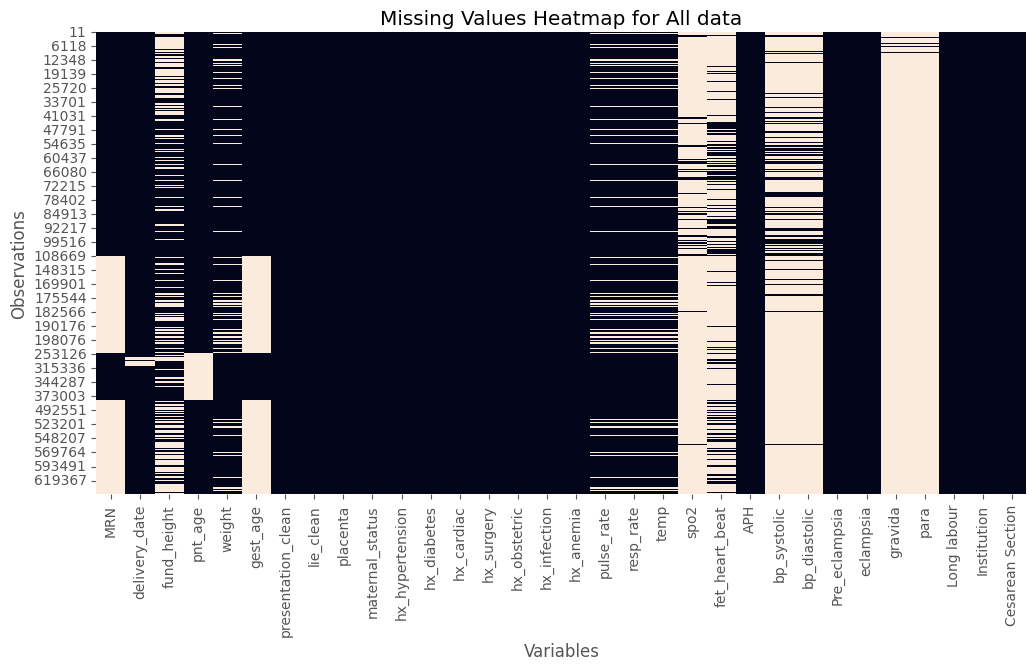

In [33]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap for All data")
plt.xlabel("Variables")
plt.ylabel("Observations")
plt.show()

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 54530 entries, 11 to 645847
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   MRN                 32009 non-null  float64
 1   delivery_date       53563 non-null  object 
 2   fund_height         31275 non-null  object 
 3   pnt_age             48968 non-null  float64
 4   weight              48200 non-null  float64
 5   gest_age            32009 non-null  object 
 6   presentation_clean  54530 non-null  object 
 7   lie_clean           54530 non-null  object 
 8   placenta            54479 non-null  object 
 9   maternal_status     54530 non-null  object 
 10  hx_hypertension     54530 non-null  float64
 11  hx_diabetes         54530 non-null  float64
 12  hx_cardiac          54530 non-null  float64
 13  hx_surgery          54530 non-null  float64
 14  hx_obstetric        54530 non-null  float64
 15  hx_infection        54530 non-null  float64
 16  hx_anem

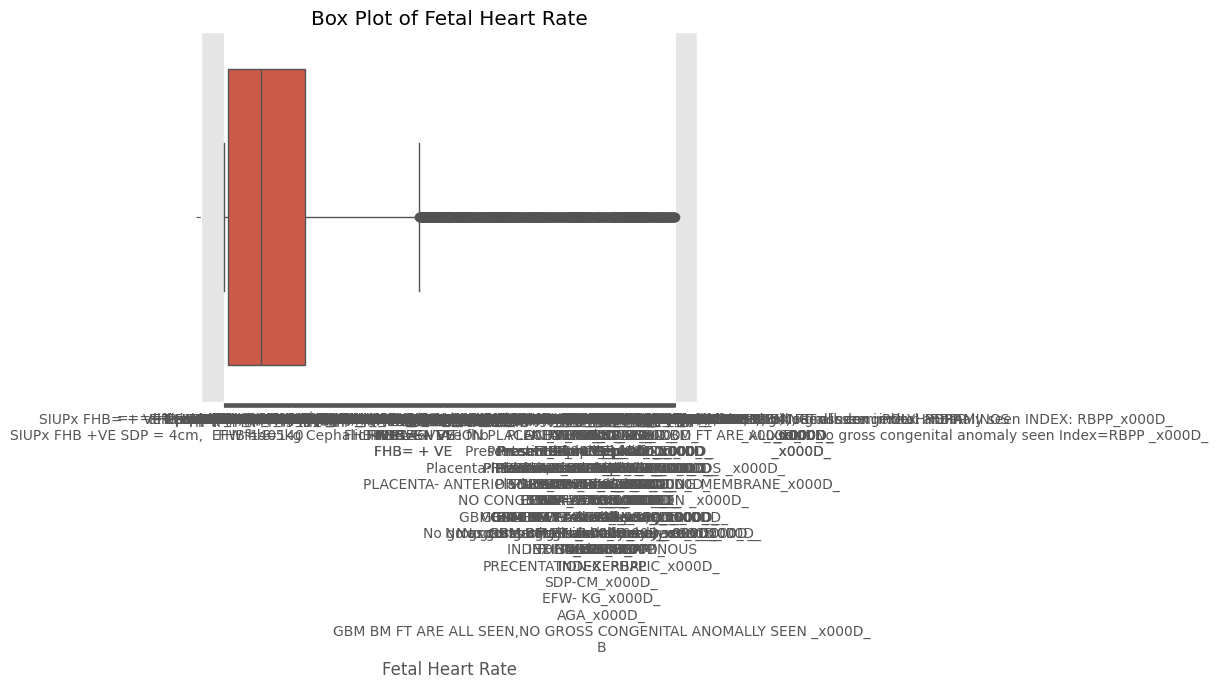

In [35]:
# Step 2: Plot the cleaned column
sns.boxplot(x=df['fet_heart_beat'])
plt.title('Box Plot of Fetal Heart Rate')
plt.xlabel('Fetal Heart Rate')
plt.show()

In [36]:
df["fund_height"].value_counts()

fund_height
-                                                                            1919
TERM                                                                         1629
TERM SIZED                                                                   1224
TERM SIZE                                                                     859
36                                                                            825
                                                                             ... 
TERM SIZED GRAVID UX, MWLTIPLE FETAL PARTS ARE PALPABLE, FHB +VE FOR BOTH       1
TERM SIZED GRAVID UX LONGITUDINAL LIE CEPHALIC FHB =138BPM                      1
38 WEEKS SIZED GRAVID UX                                                        1
36 WKS SIOZED GRAVID UTERUS                                                     1
40 wk si                                                                        1
Name: count, Length: 3433, dtype: int64

In [37]:
df['fund_height'] = (
    df['fund_height']
    .astype(str)
    .str.findall(r'\d+')
    .str[0]                      # take first number
    .astype(float)
    .astype('Int64')
)

In [38]:
df['fet_heart_beat'] = (
    df['fet_heart_beat']
    .astype(str)
    .str.findall(r'\d+')
    .str[0]                      # take first number
    .astype(float)
    .astype('Int64')
)

# Treating Outliers

In [39]:
import numpy as np
import pandas as pd

def replace_outliers_with_nan(df, cols):
    df = df.copy()

    for col in cols:

        # Convert to numeric safely
        df[col] = pd.to_numeric(df[col], errors='coerce')

        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        mask = (df[col] < lower) | (df[col] > upper)

        df.loc[mask, col] = np.nan

    return df

In [40]:
df

,MRN,delivery_date,fund_height,pnt_age,weight,gest_age,presentation_clean,lie_clean,placenta,maternal_status,...,APH,bp_systolic,bp_diastolic,Pre_eclampsia,eclampsia,gravida,para,Long labour,Institution,Cesarean Section
11,10.0,2021-04-02 00:00:00,40,32.0,0.0,Term,NA,NA,Completed,Stable,...,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,Yekatit Hospital,1.0
20,16.0,2021-03-08 00:00:00,<NA>,28.0,0.0,Pre-term,NA,NA,Completed,Stable,...,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,Yekatit Hospital,1.0
23,19.0,2021-09-10 00:00:00,<NA>,33.0,0.0,Term,NA,NA,Completed,Stable,...,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,Yekatit Hospital,0.0
25,21.0,2021-05-08 00:00:00,<NA>,26.0,0.0,Post-term,Breech,NA,Completed,Stable,...,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,Yekatit Hospital,1.0
31,27.0,2021-03-10 00:00:00,<NA>,23.0,0.0,Term,NA,NA,Completed,Stable,...,0.0,NaN,NaN,0.0,0.0,2.0,1.0,0.0,Yekatit Hospital,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
645713,NaN,2026-03-17 00:00:00,<NA>,38.0,NaN,NaN,NA,NA,Completed,Stable,...,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,Zewuditu Hospital,0.0
645727,NaN,2026-03-16 00:00:00,<NA>,25.0,NaN,NaN,NA,NA,Completed,Stable,...,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,Zewuditu Hospital,0.0
645741,NaN,2026-03-17 00:00:00,<NA>,22.0,0.0,NaN,NA,NA,Completed,Stable,...,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,Zewuditu Hospital,0.0
645758,NaN,2026-03-16 00:00:00,<NA>,29.0,NaN,NaN,NA,NA,Completed,Stable,...,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,Zewuditu Hospital,0.0


In [41]:
df['pulse_rate'] = df['pulse_rate'].replace(0, np.nan)

df['resp_rate'] = df['resp_rate'].replace(0, np.nan)

df['temp'] = df['temp'].replace(0, np.nan)

In [42]:
df

,MRN,delivery_date,fund_height,pnt_age,weight,gest_age,presentation_clean,lie_clean,placenta,maternal_status,...,APH,bp_systolic,bp_diastolic,Pre_eclampsia,eclampsia,gravida,para,Long labour,Institution,Cesarean Section
11,10.0,2021-04-02 00:00:00,40,32.0,0.0,Term,NA,NA,Completed,Stable,...,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,Yekatit Hospital,1.0
20,16.0,2021-03-08 00:00:00,<NA>,28.0,0.0,Pre-term,NA,NA,Completed,Stable,...,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,Yekatit Hospital,1.0
23,19.0,2021-09-10 00:00:00,<NA>,33.0,0.0,Term,NA,NA,Completed,Stable,...,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,Yekatit Hospital,0.0
25,21.0,2021-05-08 00:00:00,<NA>,26.0,0.0,Post-term,Breech,NA,Completed,Stable,...,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,Yekatit Hospital,1.0
31,27.0,2021-03-10 00:00:00,<NA>,23.0,0.0,Term,NA,NA,Completed,Stable,...,0.0,NaN,NaN,0.0,0.0,2.0,1.0,0.0,Yekatit Hospital,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
645713,NaN,2026-03-17 00:00:00,<NA>,38.0,NaN,NaN,NA,NA,Completed,Stable,...,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,Zewuditu Hospital,0.0
645727,NaN,2026-03-16 00:00:00,<NA>,25.0,NaN,NaN,NA,NA,Completed,Stable,...,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,Zewuditu Hospital,0.0
645741,NaN,2026-03-17 00:00:00,<NA>,22.0,0.0,NaN,NA,NA,Completed,Stable,...,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,Zewuditu Hospital,0.0
645758,NaN,2026-03-16 00:00:00,<NA>,29.0,NaN,NaN,NA,NA,Completed,Stable,...,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,Zewuditu Hospital,0.0


In [43]:
cols = [
    'fund_height', 'pnt_age', 'pulse_rate', 'resp_rate', 'temp',
    'spo2', 'fet_heart_beat', 'bp_systolic', 'bp_diastolic', 'para'
]

before = len(df)

df = replace_outliers_with_nan(df, cols)

after = len(df)

print("Rows before:", before)
print("Rows after :", after)

Rows before: 54530
Rows after : 54530


In [44]:
df

,MRN,delivery_date,fund_height,pnt_age,weight,gest_age,presentation_clean,lie_clean,placenta,maternal_status,...,APH,bp_systolic,bp_diastolic,Pre_eclampsia,eclampsia,gravida,para,Long labour,Institution,Cesarean Section
11,10.0,2021-04-02 00:00:00,40,32.0,0.0,Term,NA,NA,Completed,Stable,...,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,Yekatit Hospital,1.0
20,16.0,2021-03-08 00:00:00,<NA>,28.0,0.0,Pre-term,NA,NA,Completed,Stable,...,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,Yekatit Hospital,1.0
23,19.0,2021-09-10 00:00:00,<NA>,33.0,0.0,Term,NA,NA,Completed,Stable,...,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,Yekatit Hospital,0.0
25,21.0,2021-05-08 00:00:00,<NA>,26.0,0.0,Post-term,Breech,NA,Completed,Stable,...,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,Yekatit Hospital,1.0
31,27.0,2021-03-10 00:00:00,<NA>,23.0,0.0,Term,NA,NA,Completed,Stable,...,0.0,NaN,NaN,0.0,0.0,2.0,1.0,0.0,Yekatit Hospital,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
645713,NaN,2026-03-17 00:00:00,<NA>,38.0,NaN,NaN,NA,NA,Completed,Stable,...,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,Zewuditu Hospital,0.0
645727,NaN,2026-03-16 00:00:00,<NA>,25.0,NaN,NaN,NA,NA,Completed,Stable,...,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,Zewuditu Hospital,0.0
645741,NaN,2026-03-17 00:00:00,<NA>,22.0,0.0,NaN,NA,NA,Completed,Stable,...,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,Zewuditu Hospital,0.0
645758,NaN,2026-03-16 00:00:00,<NA>,29.0,NaN,NaN,NA,NA,Completed,Stable,...,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,Zewuditu Hospital,0.0


In [45]:

df['weight'] = df['weight'].replace(0, np.nan)

df['pulse_rate'] = df['pulse_rate'].replace(0, np.nan)

df['resp_rate'] = df['resp_rate'].replace(0, np.nan)

df['temp'] = df['temp'].replace(0, np.nan)

df['bp_systolic'] = df['bp_systolic'].replace(0, np.nan)

df['weight'] = df['weight'].replace(0, np.nan)

df['presentation_clean'] = df['presentation_clean'].replace('NA', np.nan)

df['lie_clean'] = df['lie_clean'].replace('NA', np.nan)


In [46]:
df

,MRN,delivery_date,fund_height,pnt_age,weight,gest_age,presentation_clean,lie_clean,placenta,maternal_status,...,APH,bp_systolic,bp_diastolic,Pre_eclampsia,eclampsia,gravida,para,Long labour,Institution,Cesarean Section
11,10.0,2021-04-02 00:00:00,40,32.0,NaN,Term,NaN,NaN,Completed,Stable,...,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,Yekatit Hospital,1.0
20,16.0,2021-03-08 00:00:00,<NA>,28.0,NaN,Pre-term,NaN,NaN,Completed,Stable,...,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,Yekatit Hospital,1.0
23,19.0,2021-09-10 00:00:00,<NA>,33.0,NaN,Term,NaN,NaN,Completed,Stable,...,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,Yekatit Hospital,0.0
25,21.0,2021-05-08 00:00:00,<NA>,26.0,NaN,Post-term,Breech,NaN,Completed,Stable,...,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,Yekatit Hospital,1.0
31,27.0,2021-03-10 00:00:00,<NA>,23.0,NaN,Term,NaN,NaN,Completed,Stable,...,0.0,NaN,NaN,0.0,0.0,2.0,1.0,0.0,Yekatit Hospital,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
645713,NaN,2026-03-17 00:00:00,<NA>,38.0,NaN,NaN,NaN,NaN,Completed,Stable,...,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,Zewuditu Hospital,0.0
645727,NaN,2026-03-16 00:00:00,<NA>,25.0,NaN,NaN,NaN,NaN,Completed,Stable,...,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,Zewuditu Hospital,0.0
645741,NaN,2026-03-17 00:00:00,<NA>,22.0,NaN,NaN,NaN,NaN,Completed,Stable,...,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,Zewuditu Hospital,0.0
645758,NaN,2026-03-16 00:00:00,<NA>,29.0,NaN,NaN,NaN,NaN,Completed,Stable,...,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,Zewuditu Hospital,0.0


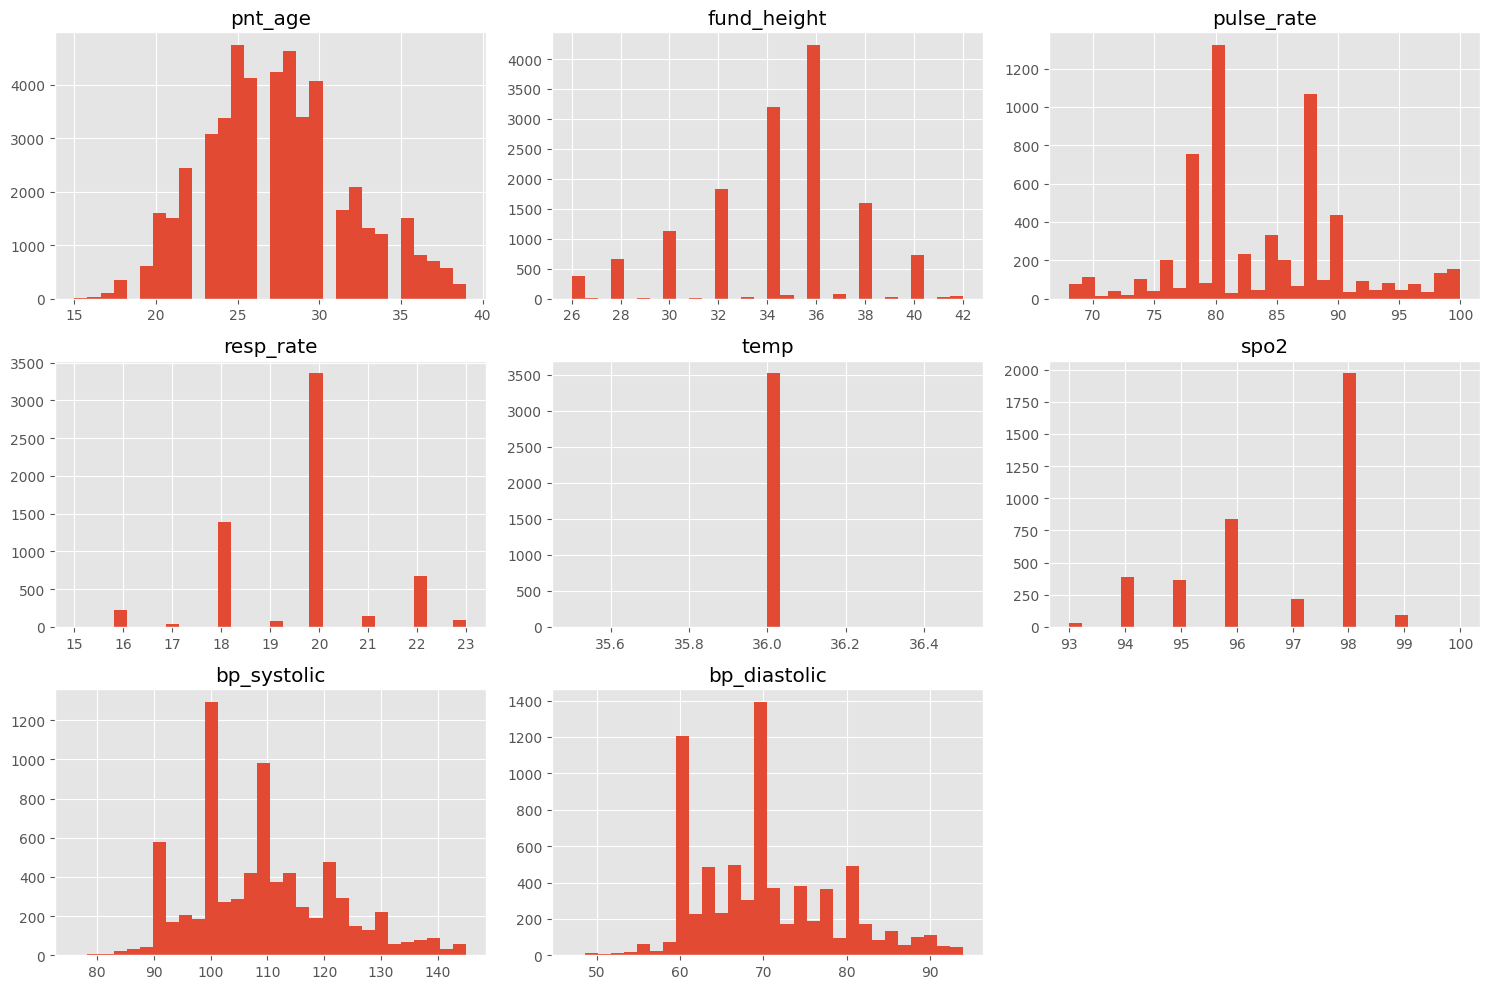

In [47]:
num_cols = [
    'pnt_age', 'fund_height', 'pulse_rate', 'resp_rate',
    'temp', 'spo2', 'bp_systolic', 'bp_diastolic'
]

df[num_cols].hist(bins=30, figsize=(15,10))
plt.tight_layout()
plt.show()

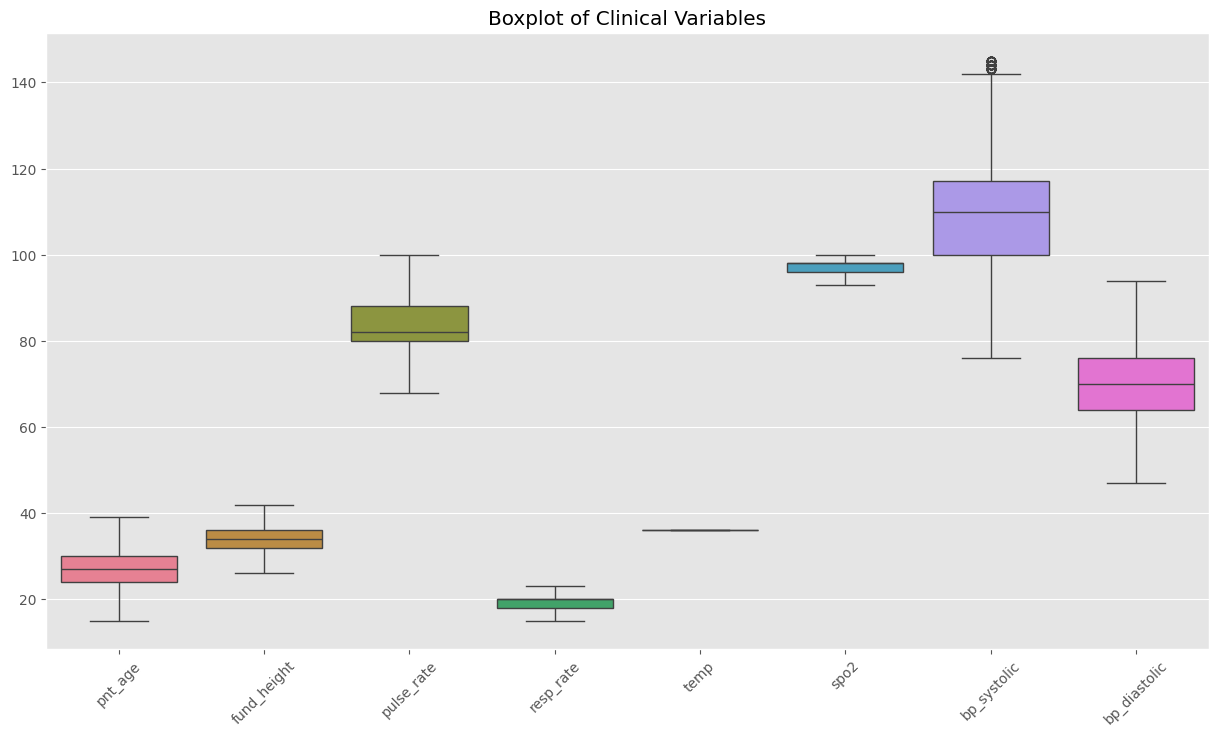

In [48]:
plt.figure(figsize=(15,8))
sns.boxplot(data=df[num_cols])
plt.xticks(rotation=45)
plt.title("Boxplot of Clinical Variables")
plt.show()

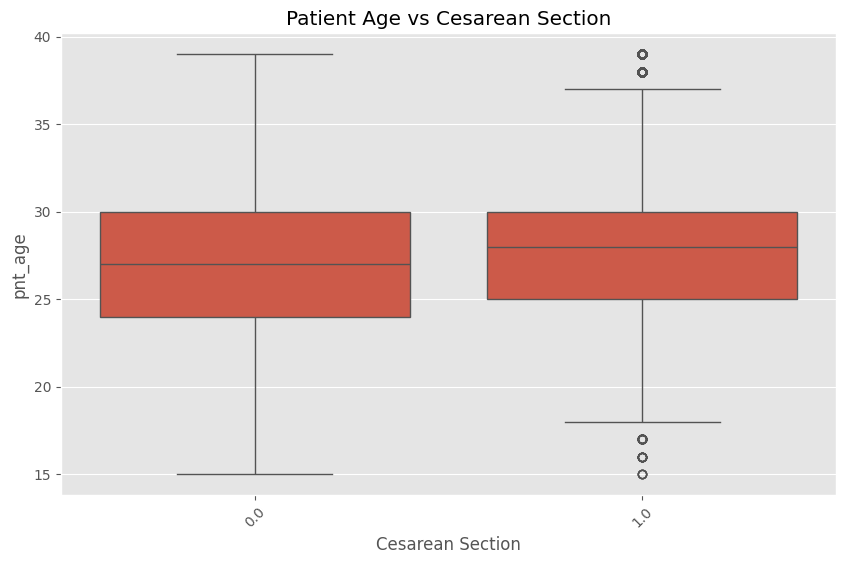

In [49]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Cesarean Section', y='pnt_age', data=df)
plt.xticks(rotation=45)
plt.title("Patient Age vs Cesarean Section")
plt.show()

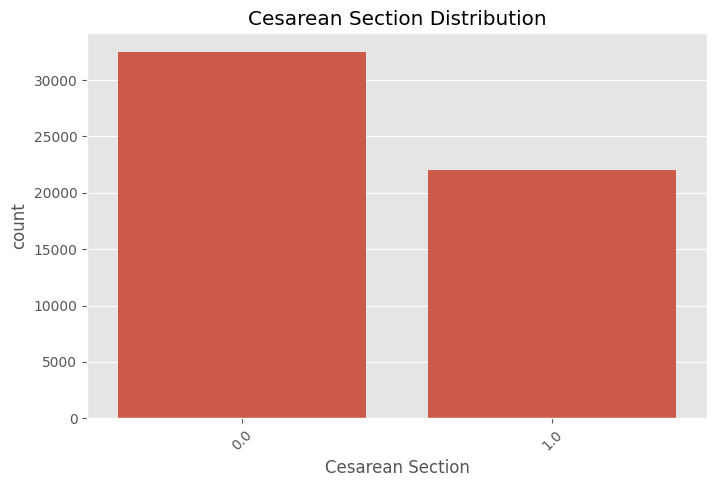

In [50]:
plt.figure(figsize=(8,5))
sns.countplot(x='Cesarean Section', data=df)
plt.xticks(rotation=45)
plt.title("Cesarean Section Distribution")
plt.show()

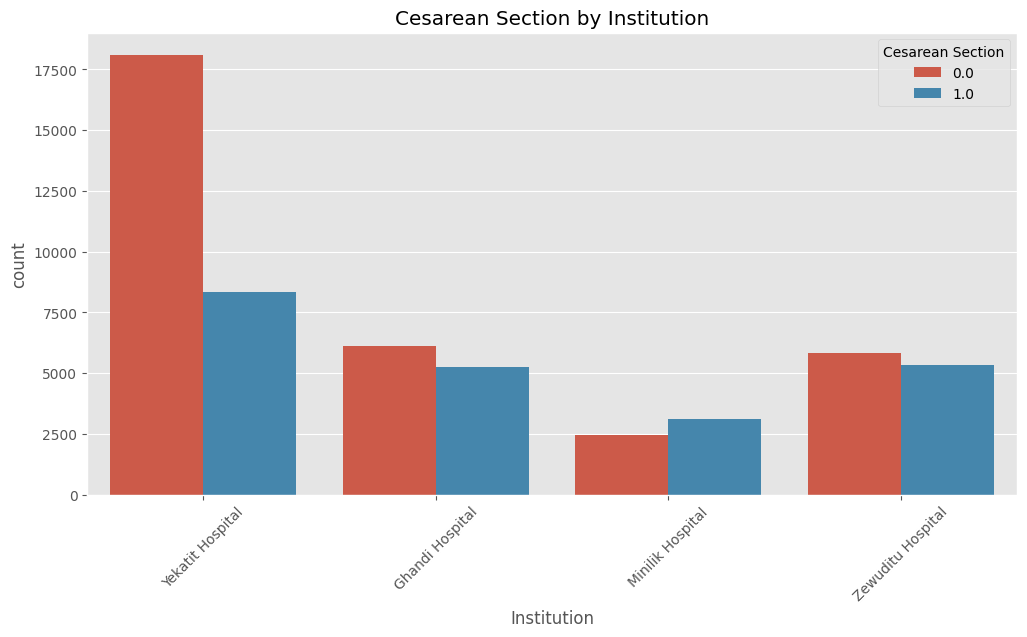

In [51]:
plt.figure(figsize=(12,6))
sns.countplot(x='Institution', hue='Cesarean Section', data=df)
plt.xticks(rotation=45)
plt.title("Cesarean Section by Institution")
plt.show()

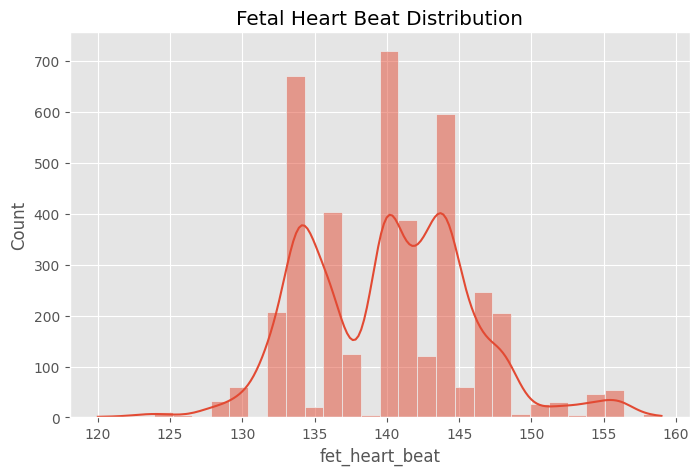

In [52]:
plt.figure(figsize=(8,5))
sns.histplot(df['fet_heart_beat'].dropna(), bins=30, kde=True)
plt.title("Fetal Heart Beat Distribution")
plt.show()

In [53]:
df = df.rename(columns={
    'MRN': 'patient_id',
    'delivery_date': 'delivery_datetime',
    'fund_height': 'fundal_height_cm',
    'pnt_age': 'maternal_age_years',
    'weight': 'maternal_weight_kg',
    'muac': 'muac_cm',
    'gest_age': 'gestational_age_weeks',
    'presentation_clean': 'fetal_presentation',
    'lie_clean': 'fetal_lie',
    'placenta': 'placenta_status',
    'maternal_status': 'maternal_outcome_status',

    'hx_hypertension': 'history_hypertension',
    'hx_diabetes': 'history_diabetes',
    'hx_cardiac': 'history_cardiac_disease',
    'hx_surgery': 'history_surgery',
    'hx_obstetric': 'history_obstetric_complications',
    'hx_infection': 'history_infection',
    'hx_anemia': 'history_anemia',

    'pulse_rate': 'maternal_pulse_rate_bpm',
    'resp_rate': 'maternal_respiratory_rate_bpm',
    'temp': 'maternal_temperature_c',
    'spo2': 'maternal_oxygen_saturation_percent',
    'fet_heart_beat': 'fetal_heart_rate_bpm',

    'APH': 'antepartum_hemorrhage',
    'bp_systolic': 'systolic_blood_pressure_mmhg',
    'bp_diastolic': 'diastolic_blood_pressure_mmhg',

    'Pre_eclampsia': 'preeclampsia',
    'eclampsia': 'eclampsia',
    'Long labour' : 'prolonged_labour',

    'gravida': 'gravidity',
    'para': 'parity',

    'Institution': 'health_facility',
    'Cesarean Section': 'Cesarean Section'
})

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 54530 entries, 11 to 645847
Data columns (total 32 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   patient_id                          32009 non-null  float64
 1   delivery_datetime                   53563 non-null  object 
 2   fundal_height_cm                    14035 non-null  Int64  
 3   maternal_age_years                  48451 non-null  float64
 4   maternal_weight_kg                  1028 non-null   float64
 5   gestational_age_weeks               32009 non-null  object 
 6   fetal_presentation                  17740 non-null  object 
 7   fetal_lie                           9929 non-null   object 
 8   placenta_status                     54479 non-null  object 
 9   maternal_outcome_status             54530 non-null  object 
 10  history_hypertension                54530 non-null  float64
 11  history_diabetes                    54530 no

# Missing value Inputation

In [55]:
import numpy as np
import pandas as pd

def probabilistic_imputation(df, random_state=42):
    np.random.seed(random_state)
    df = df.copy()

    for col in df.columns:
        # Skip columns with all missing values
        if df[col].isna().all():
            continue
        
        # Get non-missing values
        observed = df[col].dropna()
        
        # Indices where values are missing
        missing_idx = df[df[col].isna()].index
        
        if len(missing_idx) > 0:
            # Sample with replacement from observed values
            imputed_values = np.random.choice(observed, size=len(missing_idx), replace=True)
            
            # Fill missing values
            df.loc[missing_idx, col] = imputed_values

    return df

In [56]:
df = probabilistic_imputation(df)

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 54530 entries, 11 to 645847
Data columns (total 32 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   patient_id                          54530 non-null  float64
 1   delivery_datetime                   54530 non-null  object 
 2   fundal_height_cm                    54530 non-null  Int64  
 3   maternal_age_years                  54530 non-null  float64
 4   maternal_weight_kg                  54530 non-null  float64
 5   gestational_age_weeks               54530 non-null  object 
 6   fetal_presentation                  54530 non-null  object 
 7   fetal_lie                           54530 non-null  object 
 8   placenta_status                     54530 non-null  object 
 9   maternal_outcome_status             54530 non-null  object 
 10  history_hypertension                54530 non-null  float64
 11  history_diabetes                    54530 no

# Date Standardization

In [58]:
df['delivery_datetime'] = pd.to_datetime(
    df['delivery_datetime'],
    errors='coerce',
    dayfirst=False
)

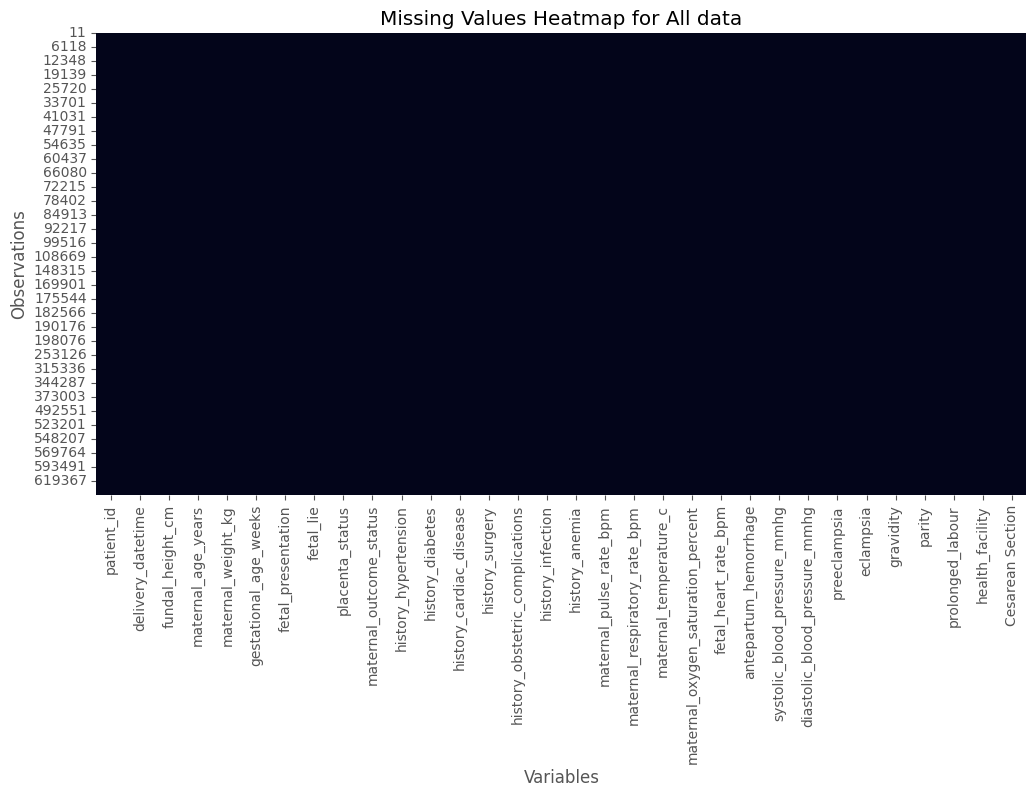

In [59]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap for All data")
plt.xlabel("Variables")
plt.ylabel("Observations")
plt.show()

In [60]:
df.isna().sum()

patient_id                             0
delivery_datetime                     32
fundal_height_cm                       0
maternal_age_years                     0
maternal_weight_kg                     0
gestational_age_weeks                  0
fetal_presentation                     0
fetal_lie                              0
placenta_status                        0
maternal_outcome_status                0
history_hypertension                   0
history_diabetes                       0
history_cardiac_disease                0
history_surgery                        0
history_obstetric_complications        0
history_infection                      0
history_anemia                         0
maternal_pulse_rate_bpm                0
maternal_respiratory_rate_bpm          0
maternal_temperature_c                 0
maternal_oxygen_saturation_percent     0
fetal_heart_rate_bpm                   0
antepartum_hemorrhage                  0
systolic_blood_pressure_mmhg           0
diastolic_blood_

<Figure size 1400x700 with 0 Axes>

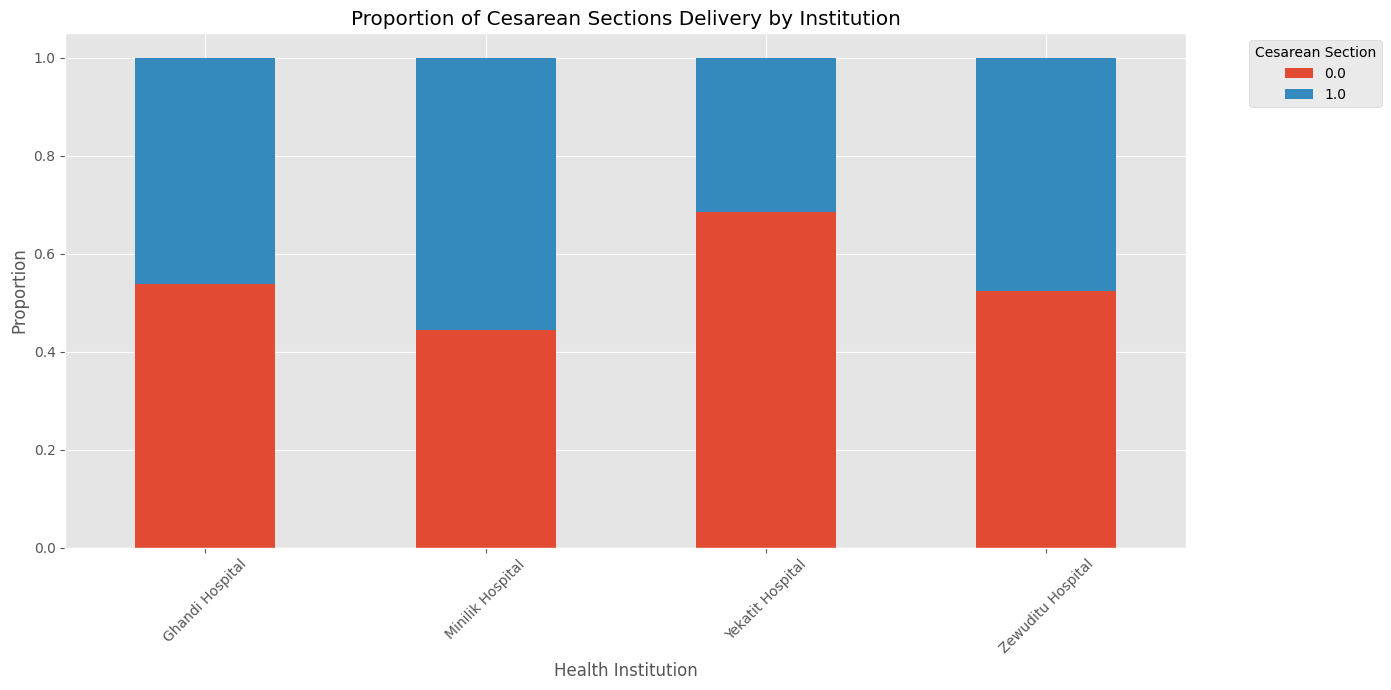

In [61]:
plt.figure(figsize=(14,7))

institution_mode = pd.crosstab(
    df['health_facility'],
    df['Cesarean Section'],
    normalize='index'
)

institution_mode.plot(
    kind='bar',
    stacked=True,
    figsize=(14,7)
)

plt.title("Proportion of Cesarean Sections Delivery by Institution")
plt.xlabel("Health Institution")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.legend(title="Cesarean Section", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

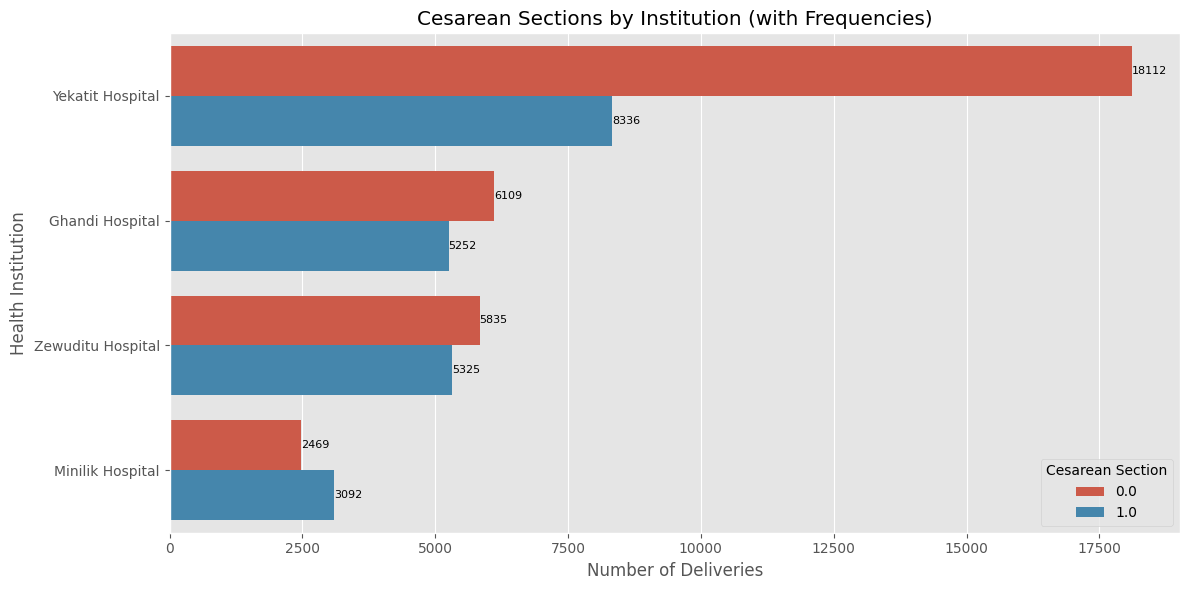

In [62]:
plt.figure(figsize=(12,6))

order = df['health_facility'].value_counts().index

ax = sns.countplot(
    y='health_facility',
    hue='Cesarean Section',
    data=df,
    order=order
)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=8)

plt.title("Cesarean Sections by Institution (with Frequencies)")
plt.xlabel("Number of Deliveries")
plt.ylabel("Health Institution")
plt.legend(title="Cesarean Section")
plt.tight_layout()
plt.show()

In [63]:
df.to_csv("D:/DLM Research/processed_data.csv", index=False)